In [20]:
from google.colab import files
uploaded = files.upload()


Saving hospital_readmissions_30k.csv to hospital_readmissions_30k (1).csv


In [21]:
import pandas as pd
import matplotlib.pyplot as plt

In [22]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score,roc_curve


In [23]:
df = pd.read_csv("hospital_readmissions_30k.csv")


In [24]:
# Remove patient ID
df = df.drop("patient_id",axis=1)

In [25]:
# Separate features and targets
X = df.drop("readmitted_30_days",axis=1)
y = df["readmitted_30_days"]

In [26]:
# Convert categorical columns into numerical columns
X = pd.get_dummies(X,drop_first=True)


In [27]:
from sklearn.model_selection import train_test_split


In [28]:
# split dataset
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

In [29]:
from sklearn.linear_model import LogisticRegression

In [30]:
# Logistic Regression with L2 regularization
model = LogisticRegression(
  penalty="l2",
  C=1.0,
  max_iter=1000
)


In [31]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, roc_curve

In [33]:
# Train the model
model.fit(X_train, y_train)

/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=1000)

In [34]:
# Predict Probablity of class 1
y_prob = model.predict_proba(X_test)[:,1]

In [35]:
# ROC-AUC score
auc = roc_auc_score(y_test, y_prob)
print("ROC-AUC:",auc)

ROC-AUC: 0.537632291283085


In [36]:
# auc curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob, pos_label='Yes')

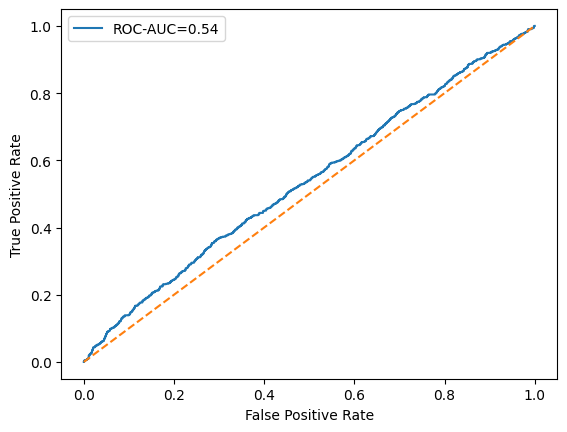

In [37]:
plt.plot(fpr, tpr, label=f"ROC-AUC={auc:.2f}")
plt.plot([0,1],[0,1],linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()